# Empregabilidade em trabalhos de IA e Ciência de Dados pelo Mundo

## Descrição do Dataset

### Contexto

O mercado de Inteligência Artificial e Ciência de Dados vem crescendo de forma acelerada nos últimos anos, impulsionado pela digitalização das empresas, pelo avanço de modelos de linguagem e pela crescente demanda por tomadas de decisão baseadas em dados. Nesse cenário, profissionais como Cientistas de Dados, Engenheiros de IA, Analistas de Dados e outros passaram a ocupar posições estratégicas nas organizações ao redor do mundo.

Compreender como esse mercado se comporta — quais fatores determinam o salário, quais países concentram mais oportunidades, quais habilidades são mais valorizadas — é fundamental tanto para profissionais que desejam se posicionar melhor quanto para empresas que precisam atrair e reter talentos.

### Sobre os Dados

O dataset AI Job Market Dataset contém 10.345 registros de vagas de emprego na área de IA e Ciência de Dados publicadas entre 2020 e 2026, abrangendo 7 países: Alemanha, Singapura, Canadá, Reino Unido, Índia, EUA e Austrália.

Cada registro representa uma vaga e traz as seguintes informações:

| Variável | Descrição |
|---|---|
| `job_title` | Título do cargo (ex: Data Scientist, AI Engineer) |
| `company_size` | Porte da empresa (Startup, Medium, MNC, Enterprise) |
| `company_industry` | Setor de atuação (Tecnologia, Saúde, Finanças, etc.) |
| `country` | País onde a vaga foi publicada |
| `remote_type` | Modalidade de trabalho (Remoto, Híbrido, Presencial) |
| `experience_level` | Nível de experiência exigido (Entry, Mid, Senior) |
| `years_experience` | Anos de experiência (0 a 14 anos) |
| `education_level` | Escolaridade mínima exigida (Bachelor, Master, PhD) |
| `skills_python` | Exige Python? (0 = não, 1 = sim) |
| `skills_sql` | Exige SQL? (0 = não, 1 = sim) |
| `skills_ml` | Exige Machine Learning? (0 = não, 1 = sim) |
| `skills_deep_learning` | Exige Deep Learning? (0 = não, 1 = sim) |
| `skills_cloud` | Exige Cloud? (0 = não, 1 = sim) |
| `salary` | Salário anual em dólares (USD) |
| `job_posting_month` | Mês de publicação da vaga |
| `job_posting_year` | Ano de publicação da vaga |
| `hiring_urgency` | Urgência de contratação (Low, Medium, High) |
| `job_openings` | Número de vagas abertas para a posição |

---

### Objetivos da Análise

Este notebook realiza uma **Análise Exploratória de Dados (EDA)** com o objetivo de entender o cenário atual do mercado de trabalho em IA e Ciência de Dados, buscando responder questões como:

- Como o salário varia entre os diferentes cargos, países e níveis de experiência?
- Qual o impacto da escolaridade e das habilidades técnicas na remuneração?
- Quais países concentram mais oportunidades e com maior urgência de contratação?
- Qual a relação entre o porte da empresa e a modalidade de trabalho oferecida?
- Como as habilidades técnicas se distribuem entre os diferentes perfis de vagas?

A análise combina medidas estatísticas descritivas e visualizações para construir uma visão clara e embasada sobre esse mercado em constante transformação.

## Inclusão das bibliotecas necessárias:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Tratamento e Limpeza dos Dados

Antes de tudo, é necessário inspecionar e preparar os dados. As etapas abaixo irão focar no pré-processamento antes das análises.

Plano de ação: Primeiro iremos carregar o dataset em uma variável df e ver a quantidade de linhas e colunas. Após isso, vamos ver se existem valores nulos ou duplicados e se sim analisaremos como vamos tratá-los. Também vamos mudar os tipos de dados para o que fizer sentido para o nosso propósito.

In [ ]:
df = pd.read_csv('../data/raw/AI Job Market Dataset.csv')
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


Antes de tratar, precisamos entender o que temos: quantas linhas, quantas colunas, e qual o tipo de cada variável.

In [ ]:
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas\n")
print("Tipos de dados por coluna:")
print(df.dtypes)

Dimensões do dataset: 10345 linhas e 19 colunas

Tipos de dados por coluna:
job_id                  int64
job_title                 str
company_size              str
company_industry          str
country                   str
remote_type               str
experience_level          str
years_experience        int64
education_level           str
skills_python           int64
skills_sql              int64
skills_ml               int64
skills_deep_learning    int64
skills_cloud            int64
salary                  int64
job_posting_month       int64
job_posting_year        int64
hiring_urgency            str
job_openings            int64
dtype: object


In [ ]:
nulos = df.isnull().sum()
print(nulos)

duplicatas = df.duplicated().sum()
print(duplicatas)

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64
0


In [ ]:
df = df.drop_duplicates()
df = df.drop(columns=['job_id'])

print(f"Dataset após limpeza: {df.shape[0]} linhas e {df.shape[1]} colunas")

Dataset após limpeza: 10345 linhas e 18 colunas


In [ ]:
colunas_categoricas = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']

for col in colunas_categoricas: df[col] = df[col].astype('category')

df['experience_level'] = pd.Categorical(df['experience_level'], categories=['Entry', 'Mid', 'Senior'], ordered=True)
df['education_level'] = pd.Categorical(df['education_level'], categories=['Bachelor', 'Master', 'PhD'], ordered=True)
df['company_size'] = pd.Categorical(df['company_size'], categories=['Startup', 'Medium', 'MNC', 'Enterprise'], ordered=True)

print(df.dtypes)

job_title               category
company_size            category
company_industry        category
country                 category
remote_type             category
experience_level        category
years_experience           int64
education_level         category
skills_python              int64
skills_sql                 int64
skills_ml                  int64
skills_deep_learning       int64
skills_cloud               int64
salary                     int64
job_posting_month          int64
job_posting_year           int64
hiring_urgency          category
job_openings               int64
dtype: object


In [ ]:
df.describe()

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [ ]:
print("Valores únicos por coluna categórica:")

for col in colunas_categoricas:
    print(f"[{col}] — {df[col].nunique()} categorias:")
    print(df[col].value_counts().to_string())
    print()

Valores únicos por coluna categórica:
[job_title] — 6 categorias:
job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676

[company_size] — 4 categorias:
company_size
Startup       2656
MNC           2593
Medium        2548
Enterprise    2548

[company_industry] — 6 categorias:
company_industry
Technology    1787
E-commerce    1744
Finance       1724
Healthcare    1715
Education     1704
Retail        1671

[country] — 7 categorias:
country
Germany      1498
Singapore    1490
Canada       1488
UK           1485
India        1470
USA          1459
Australia    1455

[remote_type] — 3 categorias:
remote_type
Remote    3513
Hybrid    3420
Onsite    3412

[experience_level] — 3 categorias:
experience_level
Entry     3513
Senior    3420
Mid       3412

[education_level] — 3 categorias:
education_level
Master      3529
PhD         3425


### Conclusão do Pré-processamento

O dataset possui 10.345 registros e 18 colunas (após remover o job_i`). Não foram encontrados valores nulos nem duplicatas, o que indica uma base bem estruturada. As principais ações realizadas foram a remoção da coluna job_id (sem valor de análise), ordenação e categorização de variáveis e revisão de valores nulos ou duplicados.

In [ ]:
# passando o df para csv para facilitar a leitura no próximo notebook
df.to_csv('../data/processed/AI_Job_Market_Cleaned.csv')
df_processed = pd.read_csv('../data/processed/AI_Job_Market_Cleaned.csv')

## Exploração das variáveis e suas relações:

Antes de responder as perguntas-chave, é importante explorar as variáveis do dataset para compreender suas relações entre si e as bases que a constitutem.

### Distribuição Salarial entre diferentes títulos de trabalho:

Aqui se quer compreender como é a distribuição salarial dependendo do título de trabalho, seja ele AI engineer, Business Analyst, e por aí vai. O motivo disso é que a distribuição de salário poderia variar dependendo da função performada, sendo difícil considerar tudo em um único grupo genérico.

Plano de ação: Agrupar distintamente os títulos de trabalho e tirar suas médias e medianas, comparando-os em gráficos de barra.

In [ ]:
media_por_title = df_processed.groupby('job_title')['salary'].mean()
mediana_por_title = df_processed.groupby('job_title')['salary'].median()

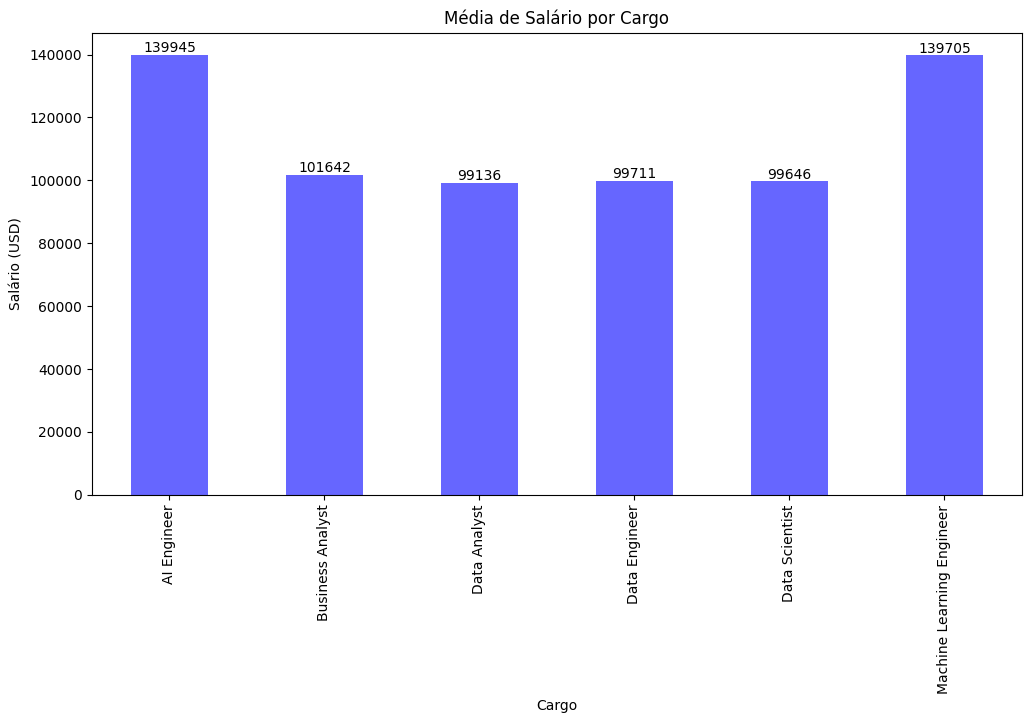

In [ ]:
plt.figure(figsize=(12, 6))

ax = media_por_title.plot(kind='bar', color='blue', alpha=0.6, label='Média')

for i, v in enumerate(media_por_title):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.title('Média de Salário por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Salário (USD)')
plt.show()

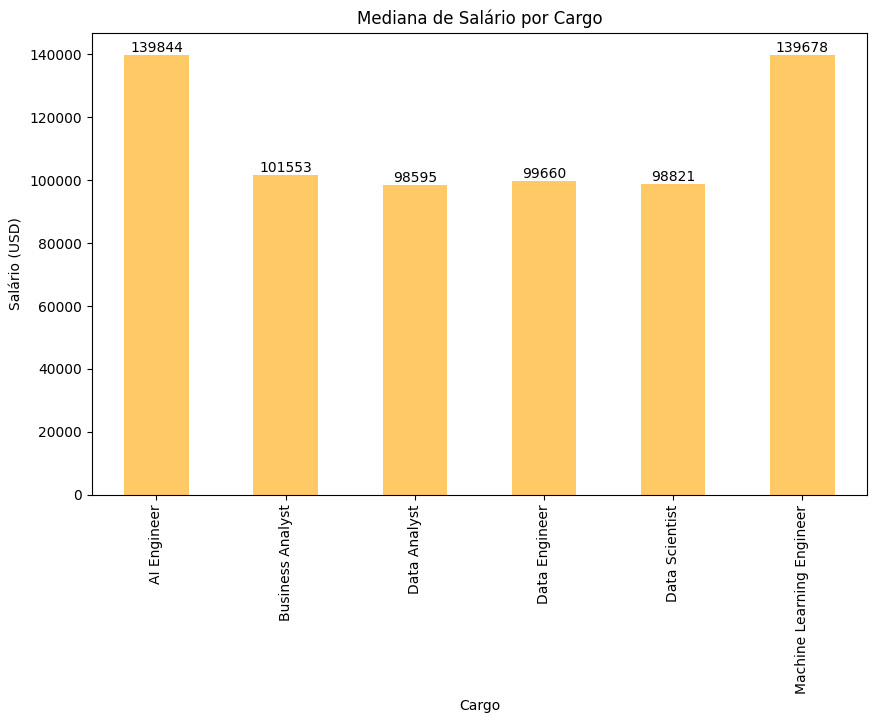

In [ ]:
plt.figure(figsize=(10, 6))

ax2 = mediana_por_title.plot(kind='bar', color='orange', alpha=0.6, label='Mediana')
for i, v in enumerate(mediana_por_title):
    ax2.text(i, v, f'{v:.0f}', ha='center', va='bottom')
    
plt.title('Mediana de Salário por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Salário (USD)')
plt.show()

Conclusão baseada no resultado: Os gráficos evidenciam que a média e a mediana estão extremamente próximas, o que faz sentido já que os dados foram criados sinteticamente (Na vida real, isso provavelmente seria um tanto diferente). Mesmo assim os dados evidenciam que os que mais ganham bem em dólar anualmente são os engenheiros de IA e ML, enquanto Business e Data ANlysts e Data engineers ganham um tanto menos. A amostragem aponta então que em média os trabalhos de engenharia de IA estão ganhando mais que os de dados puros.

### Skills mais e menos comuns:

É importante se analisar essa parte para que se compreenda as habilidades que atualmente estão mais presentes nos trabalhadores de Ciências de Dados entre seus setores.

Plano de ação: Contabilizar a quantidade de 1 e 0 para comparar a quantidade de profissionais que têm e de que não tem certas habilidades.

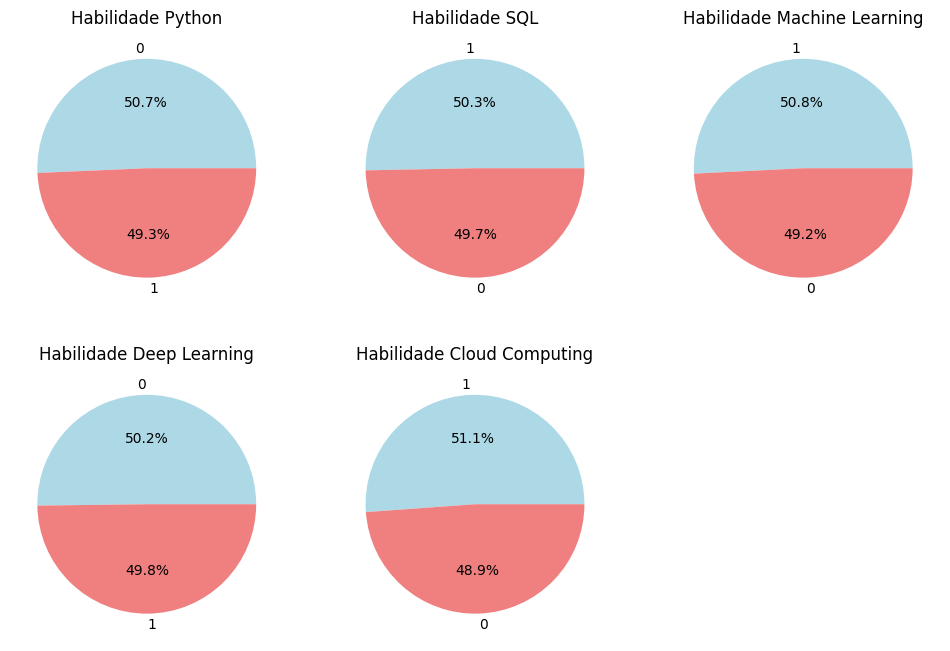

In [ ]:
skills_python = df_processed['skills_python'].value_counts()
skills_sql = df_processed['skills_sql'].value_counts()
skills_ml = df_processed['skills_ml'].value_counts()
skills_deep_learning = df_processed['skills_deep_learning'].value_counts()
skills_cloud = df_processed['skills_cloud'].value_counts()

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.pie(skills_python, labels=skills_python.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Habilidade Python')

plt.subplot(2, 3, 2)
plt.pie(skills_sql, labels=skills_sql.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Habilidade SQL')

plt.subplot(2, 3, 3)
plt.pie(skills_ml, labels=skills_ml.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Habilidade Machine Learning')

plt.subplot(2, 3, 4)
plt.pie(skills_deep_learning, labels=skills_deep_learning.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Habilidade Deep Learning')

plt.subplot(2, 3, 5)
plt.pie(skills_cloud, labels=skills_cloud.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Habilidade Cloud Computing')

plt.show()

Conclusão baseada no resultado: A proporção de posessão ou não de skill (1 ou 0) parece seguir também uma proporção muito uniforme de meio em meio em praticamente todas as categorias, o que parece suspeito. Estes tipos de comportamento podem demonstrar a diferença de um dataset normal e um criado sinteticamente e provavelmente indica informações que não necessariamente são tão aplicadas ao mundo real mas que podem ser utilizada para uma análise de dados teórica.

### Dispersão salarial entre países:

Compreendendo a ascenção de Dados e IA pelo mundo afora, é fundamental compreender em quais países esses profissionais estão ganhando mais ou menos, em dólar.

Plano de ação: Tiras as médias salariais de cada país e compará-las em gráfico de barras.

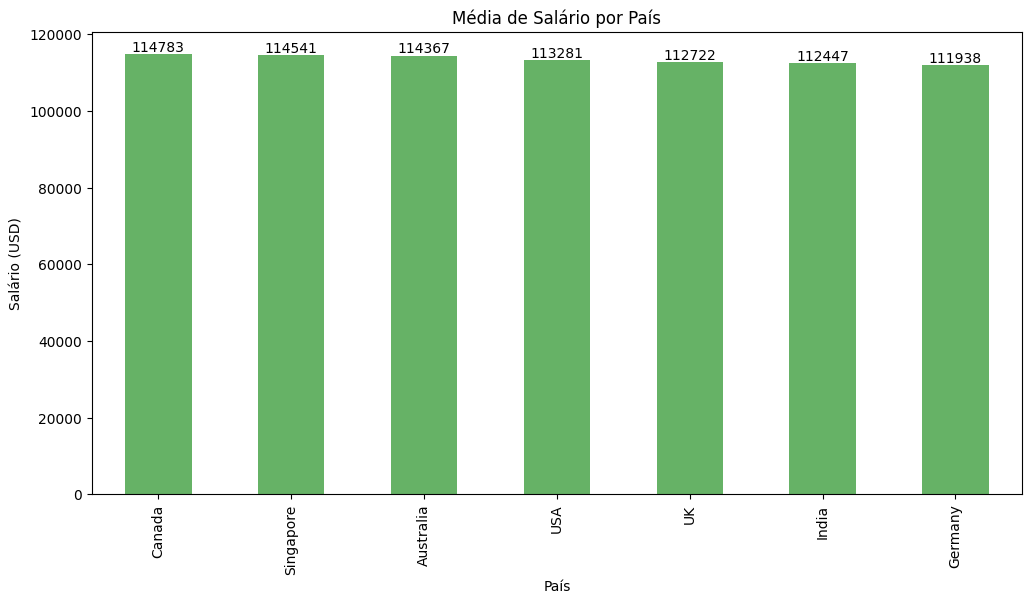

In [ ]:
# Plano de ação: Tiras as médias salariais de cada país e e compara-las em grafico de barras

df_country_salary = df_processed.groupby('country')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = df_country_salary.plot(kind='bar', color='green', alpha=0.6)
for i, v in enumerate(df_country_salary):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.title('Média de Salário por País')
plt.xlabel('País')
plt.ylabel('Salário (USD)')
plt.show()

Conclusão baseada no resultado: Aqui está outro indicador que evidencia que o dataset não é tão confiável para dados reias, aqui quase todos os profissionais ganham quase que o mesmo dinheiro em dólar o que é bem difícil de acreditar, principalmente observando países subdesenvolvidos como a Índia ganhando melhor do que a Alemanha. Teoricamente, o gráfico indica que os países não diferenciam muito o salário destes profissionais.

### Categorização de proficiência dos profissionais baseado em seus anos de atuação e níveis de educação:

Como as classificações entre Senior, Mid, etc(...) podem variar muito na área de tecnologia, faz sentido ver no dataset como essas categorizações se relacionam com anos de experiência e nível de educação dos profissionais.

Plano de ação: Fazer dois gráficos que comparem experience_level com years_experience e outro com education_level.

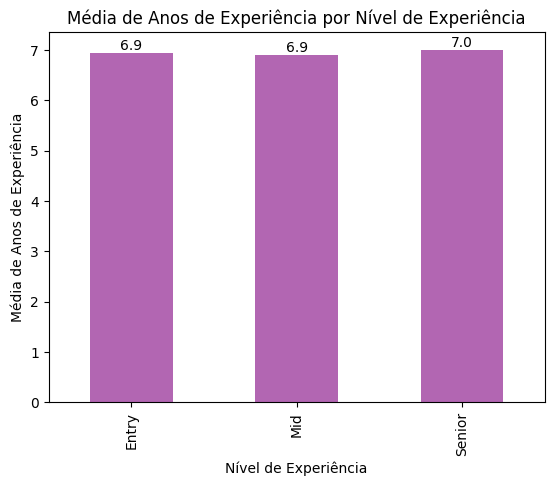

In [ ]:
ax = df_processed.groupby('experience_level')['years_experience'].mean().plot(kind='bar', color='purple', alpha=0.6)
for i, v in enumerate(df_processed.groupby('experience_level')['years_experience'].mean()):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.title('Média de Anos de Experiência por Nível de Experiência')
plt.xlabel ('Nível de Experiência')
plt.ylabel('Média de Anos de Experiência')
plt.show()

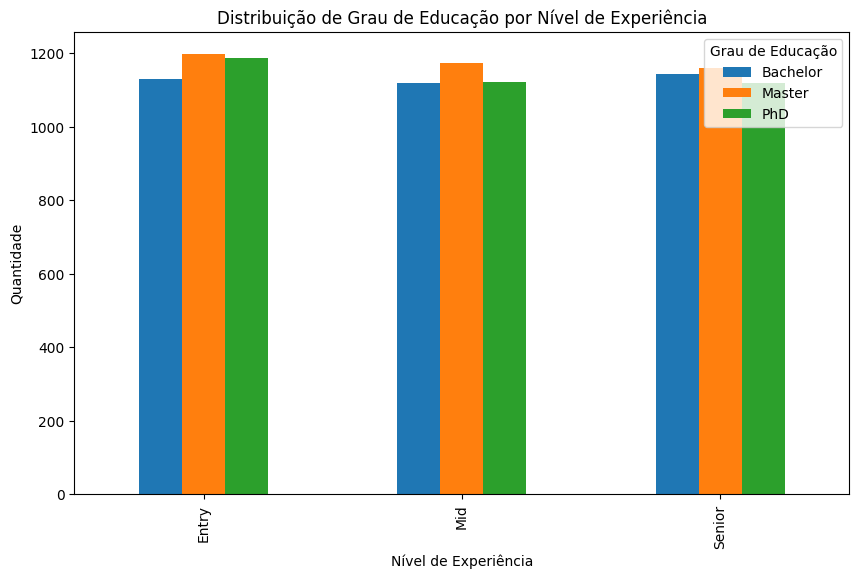

In [ ]:
tabela = df_processed.groupby(['experience_level', 'education_level']).size().unstack()

tabela.plot(kind='bar', figsize=(10,6))

plt.title('Distribuição de Grau de Educação por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Quantidade')
plt.legend(title='Grau de Educação')
plt.show()

Conclusão baseada nos resultados: Os dois resultados seguem mostrando que os dados são muito enviésados e irrealistas. Aqui, os profissionals Entry, Mid e Senior possuem em sua essência o mesmo nível de educação de bacharel, mestrado ou PHD, o que é bem improvável que seja o caso, já que se espera pelo menos em maior parte níveis de educação maiores para profissionais mais avançados.

### Conclusão da exploração:

Por mais que o dataset não impeça uma análise teórica, os dados claramente não tem uma amostragem muito fidedigna a como é a realidade, sendo os dados sintéticos distantes o que se pode extrair da realidade. Mesmo assim, isso não impede o exercício da extração de dados e vamos trabalhar com os dados como eles são.

## Perguntas de Investigação:

##### 1. Qual é a dispersão salarial por nível de experiência e como que esses também se diferenciam baseado no nível de educação do profissional? // ramses

(explicação do por que de se analisar isso)

Hipótese sobre pergunta: É sensato acreditar que níveis de experiência e educação mais altos significam salários mais altos, porém a significância da diferença é algo que só a análise poderia responder

Plano de ação:

In [ ]:
# código

Conclusão baseada no resultado:

#### 2. Qual a correlação entre o tamanho da empresa e o tipo de trabalho realizado? (ex: Remoto ou presencial) // eduardo

(explicação do por que de se analisar isso)

Hipótese sobre pergunta: É possível que empresas maiores tenham o trabalho remoto como algo mais estruturado mas isso pode depender muito do tipo de empresa, onde que isso é analisado.

Plano de ação:

In [ ]:
# código

Conclusão baseada no resultado:

#### 3. Quais países estão com mais oportunidades de novas vagas e com urgência de mais profissionais? // 

O mercado de IA e Ciência de Dados é global, mas a adoção e a demanda por profissionais variam bastante entre os países. Entender onde estão concentradas as oportunidades — e onde há maior urgência para contratar — é importante tanto para quem busca crescer na carreira ou trabalhar fora, quanto para empresas e governos que querem identificar falta de talentos.

Hipótese sobre pergunta: 
Países que estão investindo no desenvolvimento de Ciências de Dados e IA tendem a ter maior necessidade de preencher vagas nessas áreas. Em muitos casos, existe disposição para investir, mas falta gente qualificada ou interessada o suficiente para acompanhar esse crescimento.
Por isso, é esperado que países como EUA, Canadá e Alemanha apareçam no topo do ranking, já que são economias com forte investimento em tecnologia e, provavelmente, um maior desequilíbrio entre a oferta de profissionais e a demanda por esses talentos.

Plano de ação: 
Calcular o total de vagas abertas (job_openings) por país;
Calcular o número e percentual de postagens com urgência alta (hiring_urgency == 'High') por país;
Criar um score de oportunidade combinando volume e urgência: total_vagas × (% urgência alta / 100);
Visualizar os resultados em gráficos de barras comparativos e um mapa de calor.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('../data/processed/AI_Job_Market_Cleaned.csv')

summary = df.groupby('country').agg(
    total_vagas       = ('job_openings', 'sum'),
    total_postagens   = ('job_openings', 'count'),
    urgencia_alta     = ('hiring_urgency', lambda x: (x == 'High').sum()),
    pct_urgencia_alta = ('hiring_urgency', lambda x: round((x == 'High').mean() * 100, 1))
).reset_index()

summary['score_oportunidade'] = summary['total_vagas'] * (summary['pct_urgencia_alta'] / 100)
summary = summary.sort_values('score_oportunidade', ascending=False).reset_index(drop=True)

print("Ranking de oportunidade por país:")
print(summary[['country','total_vagas','pct_urgencia_alta','score_oportunidade']].to_string(index=False))

x = np.arange(len(summary))
width = 0.25
cores = ['#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Quais países têm mais oportunidades e urgência por profissionais de IA/DS?',
             fontsize=14, fontweight='bold')

score_norm = summary['score_oportunidade'] / summary['score_oportunidade'].max() * 100
vagas_norm = summary['total_vagas'] / summary['total_vagas'].max() * 100

b1 = ax.bar(x - width, vagas_norm, width, label='Total de Vagas (normalizado)', color=cores[0], alpha=0.85)
b2 = ax.bar(x,          summary['pct_urgencia_alta'], width, label='% Urgência Alta', color=cores[1], alpha=0.85)
b3 = ax.bar(x + width,  score_norm, width, label='Score de Oportunidade (normalizado)', color=cores[2], alpha=0.85)

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(summary['country'], fontsize=11)
ax.set_ylabel('Valor (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Conclusão baseada no resultado:
A Austrália lidera o ranking de oportunidade (score ≈ 3.910), seguida de perto por EUA (≈ 3.824) e Canadá (≈ 3.785). Esse resultado vem da combinação entre muitas vagas abertas e um alto nível de urgência nas contratações (mais de 51%).

A Alemanha tem o maior número de vagas (7.530), mas o menor nível de urgência (48,1%), o que indica um processo de contratação mais planejado. Já a Índia aparece na última posição, embora com valores próximos aos demais, mostrando que todos os países analisados têm mercados ativos em IA e Ciência de Dados.

No geral, a hipótese se confirmou em parte: EUA e Canadá estão entre os líderes, mas o destaque da Austrália chama atenção, possivelmente por uma demanda crescente com menor oferta de profissionais qualificados.

## Observações e considerações (O que aprendemos dos dados):

## Conclusões: